# 06c — Deep Learning: LSTM Forecaster (Sliding Window)
**Objetivo:** Predecir consumo energético 24 horas adelante usando LSTM con ventana deslizante.  
**Diferencia vs Opción A:** El modelo recibe una secuencia de 168 horas (1 semana) como input `(batch, seq_len=168, features)`.  
**Comparación:** LSTM-Seq vs LSTM-Tabular vs MLP vs modelos previos.

## 0. Imports y configuración

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
import sys

sys.path.append('../src')

from modeling.DL_LSTM_seq import (
    set_seed,
    build_model,
    get_dataloaders,
    train_model,
    evaluate_model,
    save_model,
    load_model,
    DEVICE
)
from utils.metrics import calculate_metrics, print_metrics

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")

FH         = 24
SEQ_LEN    = 48    # 1 semana de historia
TARGET_COL = 'PJME_MW'

Path('../reports/figures').mkdir(parents=True, exist_ok=True)

PyTorch version : 2.10.0+cu128
Device          : cuda


## 1. Cargar datos

In [3]:
data_dir = Path('../data/processed')

train_df = pd.read_csv(data_dir / f'train_{FH}hr.csv', index_col='Datetime', parse_dates=True)
val_df   = pd.read_csv(data_dir / f'val_{FH}hr.csv',   index_col='Datetime', parse_dates=True)
test_df  = pd.read_csv(data_dir / f'test_{FH}hr.csv',  index_col='Datetime', parse_dates=True)

train_df = train_df.asfreq('h')
val_df   = val_df.asfreq('h')
test_df  = test_df.asfreq('h')

print(f"Train : {train_df.shape}  {train_df.index[0].date()} → {train_df.index[-1].date()}")
print(f"Val   : {val_df.shape}    {val_df.index[0].date()} → {val_df.index[-1].date()}")
print(f"Test  : {test_df.shape}   {test_df.index[0].date()} → {test_df.index[-1].date()}")

Train : (101622, 50)  2002-01-09 → 2013-08-13
Val   : (21752, 50)    2013-08-14 → 2016-02-06
Test  : (21753, 50)   2016-02-07 → 2018-08-02


## 2. DataLoaders + Scaler

In [4]:
train_loader, val_loader, test_loader, scaler_y_mean, scaler_y_std, feature_cols = get_dataloaders(
    train_df, val_df, test_df,
    target_col = TARGET_COL,
    seq_len    = SEQ_LEN,
    batch_size = 64,
)

# Verificar shape — debe ser (batch, seq_len=168, n_features)
sample_X, sample_y = next(iter(train_loader))
print(f"\nX shape : {sample_X.shape}  → (batch, seq_len, features)")
print(f"y shape : {sample_y.shape}  → (batch, 1)")
print(f"\nscaler_y_mean : {scaler_y_mean:.2f} MW")
print(f"scaler_y_std  : {scaler_y_std:.2f} MW")

seq_len         : 48 horas
n_features      : 50
Samples train   : 101574 | val: 21704 | test: 21705
X shape ejemplo : torch.Size([48, 50])  → (seq_len, n_features)

X shape : torch.Size([64, 48, 50])  → (batch, seq_len, features)
y shape : torch.Size([64, 1])  → (batch, 1)

scaler_y_mean : 32411.87 MW
scaler_y_std  : 6502.00 MW


## 3. Construir modelo

In [5]:
set_seed(22)

model = build_model(
    train_loader,
    hidden_size = 64,
    num_layers  = 2,
    dropout     = 0.2,
)

Semilla fijada: 22
Arquitectura : LSTM(seq=48, features=50 → hidden=64, layers=2) → 1
Parámetros   : 63,041
Device       : cuda


## 4. Entrenamiento

In [ ]:
history = train_model(
    model,
    train_loader,
    val_loader,
    epochs    = 50,
    lr        = 1e-3,
    patience  = 10,
    save_path = f'../models/dl_best_lstm_seq_{SEQ_LEN}.pt',
)
## seq_len 24: 23 min de entrenamiento cpu
## seq_len 48: 28 min de entrenamiento cpu 8min gpu
## seq_len 168: 88 min de entrenamiento cpu

Epoch   1/50 | Train: 0.0446 | Val: 0.0085 | Best: 0.0085 | LR: 1.00e-03
Epoch  10/50 | Train: 0.0084 | Val: 0.0024 | Best: 0.0019 | LR: 1.00e-03
Epoch  20/50 | Train: 0.0068 | Val: 0.0016 | Best: 0.0016 | LR: 5.00e-04
Epoch  30/50 | Train: 0.0062 | Val: 0.0015 | Best: 0.0014 | LR: 2.50e-04
Epoch  40/50 | Train: 0.0061 | Val: 0.0014 | Best: 0.0013 | LR: 2.50e-04
Epoch  50/50 | Train: 0.0058 | Val: 0.0012 | Best: 0.0012 | LR: 1.25e-04

Mejor Val Loss: 0.0012 → guardado en ../models/dl_best_lstm_seq_48.pt


In [7]:
# Cargar modelo guardado — comentar bloque anterior si se usa esto
# model, scaler_y_mean, scaler_y_std, feature_cols, history = load_model(path=f'../models/dl_lstm_seq_{SEQ_LEN}.pt')

### Curva de entrenamiento

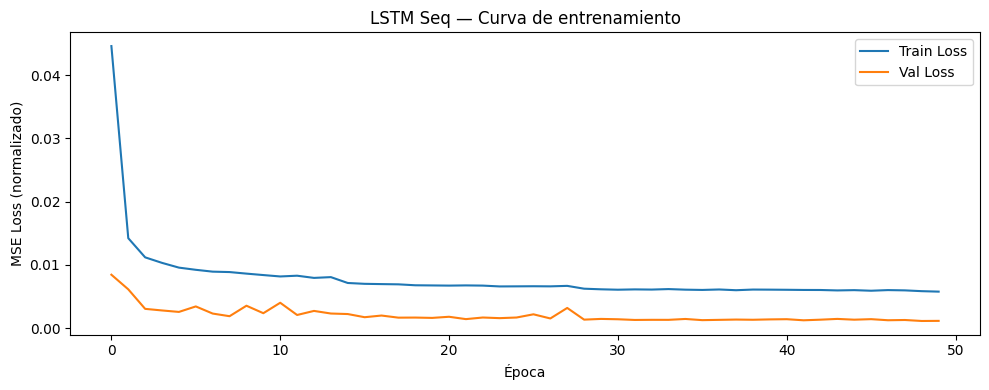

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], label='Train Loss')
ax.plot(history['val_loss'],   label='Val Loss')
ax.set_xlabel('Época')
ax.set_ylabel('MSE Loss (normalizado)')
ax.set_title('LSTM Seq — Curva de entrenamiento')
ax.legend()
plt.tight_layout()
plt.savefig(f'../reports/figures/dl_lstm_seq_training_curve_{SEQ_LEN}.png', dpi=150)
plt.show()

## 5. Evaluación

In [9]:
model.load_state_dict(torch.load(f'../models/dl_best_lstm_seq_{SEQ_LEN}.pt', map_location=DEVICE))

metrics_val,  y_true_val,  y_pred_val  = evaluate_model(model, val_loader,  scaler_y_mean, scaler_y_std, set_name='Val')
metrics_test, y_true_test, y_pred_test = evaluate_model(model, test_loader, scaler_y_mean, scaler_y_std, set_name='Test')


Métricas - Val
Mean_True:  31,500.00 MW
Std_True: 6,186.30 MW
MAE:  161.08 MW
RMSE: 221.27 MW
MAPE: 0.51%
R²:   0.9987


Métricas - Test
Mean_True:  31,095.34 MW
Std_True: 6,450.06 MW
MAE:  172.90 MW
RMSE: 235.06 MW
MAPE: 0.56%
R²:   0.9987



### Predicciones vs Real

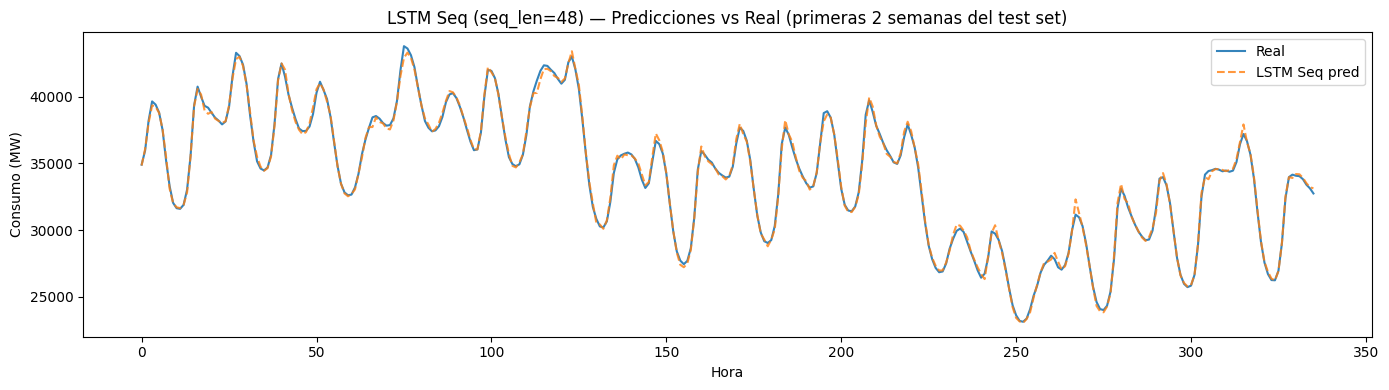

In [10]:
N = 24 * 14  # 2 semanas

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_true_test[:N], label='Real',          alpha=0.9)
ax.plot(y_pred_test[:N], label='LSTM Seq pred', alpha=0.8, linestyle='--')
ax.set_xlabel('Hora')
ax.set_ylabel('Consumo (MW)')
ax.set_title(f'LSTM Seq (seq_len={SEQ_LEN}) — Predicciones vs Real (primeras 2 semanas del test set)')
ax.legend()
plt.tight_layout()
plt.savefig(f'../reports/figures/dl_lstm_seq_predictions_{SEQ_LEN}.png', dpi=150)
plt.show()

## 6. Guardar modelo y resultados

In [11]:
save_model(
    model, scaler_y_mean, scaler_y_std, feature_cols,
    history = history,
    path    = f'../models/dl_lstm_seq_{SEQ_LEN}.pt'
)

metrics_test['model'] = 'LSTM_Seq'
results_df = pd.DataFrame([metrics_test])
results_df.to_csv(f'../reports/metrics/dl_lstm_seq_metrics_{SEQ_LEN}.csv', index=False)
print(results_df.T)

Modelo guardado en ../models/dl_lstm_seq_48.pt
                      0
Mean_True  31095.335546
Std_True    6450.056712
MAE          172.901252
RMSE         235.056291
MAPE           0.555928
R2             0.998672
set                Test
model          LSTM_Seq


In [12]:
# Resultados
'''
LSTM Secuencial — Experimentos seq_len
=======================================

Configuración fija:
  hidden_size : 64
  num_layers  : 2
  dropout     : 0.2
  epochs      : 50
  lr          : 1e-3
  patience    : 10
  batch_size  : 64

─────────────────────────────────────────────────────────────
seq_len = 24  (1 día de historia)          Tiempo: 23 min
─────────────────────────────────────────────────────────────
  Val   → MAE:  168.80 MW | RMSE:  230.40 MW | MAPE: 0.53% | R²: 0.9986
  Test  → MAE:  179.76 MW | RMSE:  243.62 MW | MAPE: 0.58% | R²: 0.9986
─────────────────────────────────────────────────────────────
seq_len = 48  (2 días de historia)         Tiempo: 28 min
─────────────────────────────────────────────────────────────
Mean_True  31095.335546
Std_True    6450.056712
  Val   → MAE:  162.52 MW | RMSE:  220.75 MW | MAPE: 0.52% | R²: 0.9987
  Test  → MAE:  171.47 MW | RMSE:  231.74 MW | MAPE: 0.55% | R²: 0.9987
─────────────────────────────────────────────────────────────
seq_len = 168 (1 semana de historia)       Tiempo: 88 min
─────────────────────────────────────────────────────────────
  Val   → MAE:  163.94 MW | RMSE:  223.93 MW | MAPE: 0.52% | R²: 0.9987
  Test  → MAE:  172.29 MW | RMSE:  233.90 MW | MAPE: 0.56% | R²: 0.9987
─────────────────────────────────────────────────────────────
Conclusión

  Modelo seleccionado : seq_len = 48
  Justificación       : Mejor RMSE y MAPE en test con 3x menos tiempo
                        de entrenamiento que seq_len=168. La ganancia
                        de 48 → 168 es marginal (2 MW en RMSE) dado
                        que los patrones semanales ya están cubiertos
                        por las lag features del pipeline de features.
'''

'\nLSTM Secuencial — Experimentos seq_len\n=======================================\n\nConfiguración fija:\n  hidden_size : 64\n  num_layers  : 2\n  dropout     : 0.2\n  epochs      : 50\n  lr          : 1e-3\n  patience    : 10\n  batch_size  : 64\n\n─────────────────────────────────────────────────────────────\nseq_len = 24  (1 día de historia)          Tiempo: 23 min\n─────────────────────────────────────────────────────────────\n  Val   → MAE:  168.80 MW | RMSE:  230.40 MW | MAPE: 0.53% | R²: 0.9986\n  Test  → MAE:  179.76 MW | RMSE:  243.62 MW | MAPE: 0.58% | R²: 0.9986\n─────────────────────────────────────────────────────────────\nseq_len = 48  (2 días de historia)         Tiempo: 28 min\n─────────────────────────────────────────────────────────────\nMean_True  31095.335546\nStd_True    6450.056712\n  Val   → MAE:  162.52 MW | RMSE:  220.75 MW | MAPE: 0.52% | R²: 0.9987\n  Test  → MAE:  171.47 MW | RMSE:  231.74 MW | MAPE: 0.55% | R²: 0.9987\n─────────────────────────────────────

# Verificar Data Leakage

In [13]:
def verify_dataset(train_df, target_col='PJME_MW', seq_len=168):
    """
    Diagnóstico: verifica que el target es posterior a la ventana.
    Llama esto desde el notebook después de get_dataloaders.
    """
    from sklearn.preprocessing import StandardScaler

    all_cols   = [target_col] + [col for col in train_df.columns if col != target_col]
    train_arr  = train_df[all_cols].values

    scaler     = StandardScaler()
    train_scaled = scaler.fit_transform(train_arr)

    # Sample 0: ventana [0:seq_len] → target en [seq_len]
    ventana = train_scaled[0:seq_len, 0]        # columna target de la ventana
    target  = train_scaled[seq_len, 0]          # valor siguiente

    print(f"Último valor ventana (hora {seq_len})  : {ventana[-1]:.4f}")
    print(f"Target (hora {seq_len+1})              : {target:.4f}")
    print(f"¿Son distintos?                        : {ventana[-1] != target}")

    # Verificar en escala real
    last_mw  = ventana[-1]  * scaler.scale_[0] + scaler.mean_[0]
    target_mw = target      * scaler.scale_[0] + scaler.mean_[0]
    real_last  = train_df[target_col].iloc[seq_len - 1]
    real_target = train_df[target_col].iloc[seq_len]

    print(f"\nEn MW reales:")
    print(f"Último valor ventana : {last_mw:.2f} MW  (DataFrame iloc[{seq_len-1}]: {real_last:.2f} MW)")
    print(f"Target               : {target_mw:.2f} MW  (DataFrame iloc[{seq_len}]:   {real_target:.2f} MW)")
    print(f"¿Coinciden con DataFrame? : {abs(last_mw - real_last) < 1 and abs(target_mw - real_target) < 1}")


verify_dataset(train_df, target_col='PJME_MW', seq_len=168)


Último valor ventana (hora 168)  : -0.8348
Target (hora 169)              : -0.9654
¿Son distintos?                        : True

En MW reales:
Último valor ventana : 26984.00 MW  (DataFrame iloc[167]: 26984.00 MW)
Target               : 26135.00 MW  (DataFrame iloc[168]:   26135.00 MW)
¿Coinciden con DataFrame? : True


In [14]:
print(f"scaler_y_mean           : {scaler_y_mean:.2f}")
print(f"train mean real         : {train_df['PJME_MW'].mean():.2f}")
print(f"test mean real:  {test_df['PJME_MW'].mean():.2f}")
print(f"dataset completo mean   : {pd.concat([train_df, val_df, test_df])['PJME_MW'].mean():.2f}")

# scaler_y_mean debe estar cerca de train mean, no del completo
print(' ')

print(f"expanding_mean train[0] : {train_df['expanding_mean'].iloc[0]:.2f}")
print(f"expanding_mean train[-1]: {train_df['expanding_mean'].iloc[-1]:.2f}")
print(f"expanding_mean test[0]  : {test_df['expanding_mean'].iloc[0]:.2f}")
print(f"PJME_MW mean total      : {pd.concat([train_df, val_df, test_df])['PJME_MW'].mean():.2f}")
# expanding_mean debe crecer progresivamente — train[0] < train[-1] < test[0]
# Si test[0] ≈ mean total → calculado sobre todo el dataset antes del split → leakage


naive_pred   = test_df['lag_168'].values
naive_true   = test_df['PJME_MW'].values
naive_metrics = calculate_metrics(naive_true, naive_pred, set_name='Naive_lag168')
print_metrics(naive_metrics)

scaler_y_mean           : 32411.87
train mean real         : 32411.87
test mean real:  31101.32
dataset completo mean   : 32078.29
 
expanding_mean train[0] : 32729.67
expanding_mean train[-1]: 32411.99
expanding_mean test[0]  : 32251.13
PJME_MW mean total      : 32078.29

Métricas - Naive_lag168
Mean_True:  31,101.32 MW
Std_True: 6,446.03 MW
MAE:  3,760.93 MW
RMSE: 5,043.51 MW
MAPE: 11.83%
R²:   0.3878



# Feature Importance

Baseline RMSE: 235.06 MW


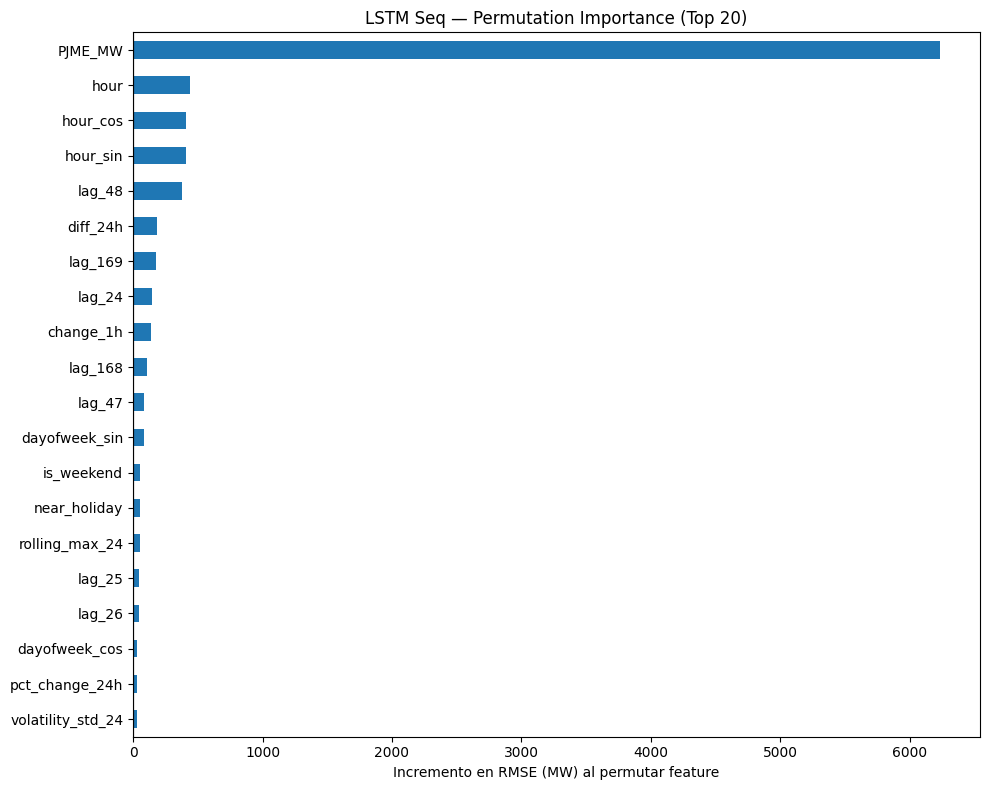


Top 10 features más importantes:
PJME_MW      6232.656196
hour          440.365484
hour_cos      407.749287
hour_sin      405.542786
lag_48        374.268944
diff_24h      185.303616
lag_169       178.993362
lag_24        146.383712
change_1h     136.974602
lag_168       106.842074


In [15]:
def permutation_importance(model, loader, scaler_y_mean, scaler_y_std, 
                           feature_cols, n_repeats=3):
    """
    Para cada feature: permuta sus valores aleatoriamente y mide
    cuánto sube el RMSE respecto al baseline.
    """
    model.eval()
    all_cols = ['PJME_MW'] + feature_cols

    # RMSE baseline (sin permutar nada)
    preds_base, trues_base = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds_base.append(model(X_batch.to(DEVICE)).cpu().numpy())
            trues_base.append(y_batch.numpy())

    y_pred = np.concatenate(preds_base).flatten() * scaler_y_std + scaler_y_mean
    y_true = np.concatenate(trues_base).flatten() * scaler_y_std + scaler_y_mean
    baseline_rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    print(f"Baseline RMSE: {baseline_rmse:.2f} MW")

    importances = {}

    for feat_idx, feat_name in enumerate(all_cols):
        rmse_list = []

        for _ in range(n_repeats):
            preds_perm, trues_perm = [], []

            with torch.no_grad():
                for X_batch, y_batch in loader:
                    X_perm = X_batch.clone()
                    # Permutar la feature en todos los pasos de la secuencia
                    perm_idx = torch.randperm(X_perm.shape[0])
                    X_perm[:, :, feat_idx] = X_perm[perm_idx, :, feat_idx]

                    preds_perm.append(model(X_perm.to(DEVICE)).cpu().numpy())
                    trues_perm.append(y_batch.numpy())

            y_pred_p = np.concatenate(preds_perm).flatten() * scaler_y_std + scaler_y_mean
            y_true_p = np.concatenate(trues_perm).flatten() * scaler_y_std + scaler_y_mean
            rmse_list.append(np.sqrt(np.mean((y_true_p - y_pred_p) ** 2)))

        importances[feat_name] = np.mean(rmse_list) - baseline_rmse

    return pd.Series(importances).sort_values(ascending=False)


# Correr
importances = permutation_importance(
    model, test_loader, scaler_y_mean, scaler_y_std, feature_cols
)

# Visualizar top 20
fig, ax = plt.subplots(figsize=(10, 8))
importances.head(20).sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Incremento en RMSE (MW) al permutar feature')
ax.set_title('LSTM Seq — Permutation Importance (Top 20)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(f'../reports/figures/dl_lstm_seq_permutation_importance_{SEQ_LEN}.png', dpi=150)
plt.show()

print("\nTop 10 features más importantes:")
print(importances.head(10).to_string())

In [16]:
def gradient_importance(model, loader, n_batches=20):
    model.eval()
    grad_sum = None

    for i, (X_batch, _) in enumerate(loader):
        if i >= n_batches:
            break
        X_batch = X_batch.to(DEVICE).requires_grad_(True)
        output  = model(X_batch).sum()
        output.backward()

        grads = X_batch.grad.abs().mean(dim=(0, 1))  # promedio sobre batch y seq
        grad_sum = grads if grad_sum is None else grad_sum + grads

    return grad_sum.cpu().detach().numpy() / n_batches




# Calcular
grad_scores = gradient_importance(model, test_loader, n_batches=20)

# Construir Series con nombres — mismo orden que all_cols en get_dataloaders
all_cols = ['PJME_MW'] + feature_cols
importance_series = pd.Series(grad_scores, index=all_cols).sort_values(ascending=False)

# Visualizar top 20
fig, ax = plt.subplots(figsize=(10, 8))
importance_series.head(20).sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Gradiente promedio absoluto')
ax.set_title('LSTM Seq — Gradient Importance (Top 20)')
plt.tight_layout()
plt.savefig(f'../reports/figures/dl_lstm_seq_gradient_importance_{SEQ_LEN}.png', dpi=150)
plt.show()

print("\nTop 10 features más importantes:")
print(importance_series.head(10).to_string())

RuntimeError: cudnn RNN backward can only be called in training mode